In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *


In [11]:
FTMethod = "DFT"
kappa = 20
FrameTension="IsotropicFrameTension"
InitialConfiguration = "FromFlat"
N_k = 10
i1 = 0; i2 =9

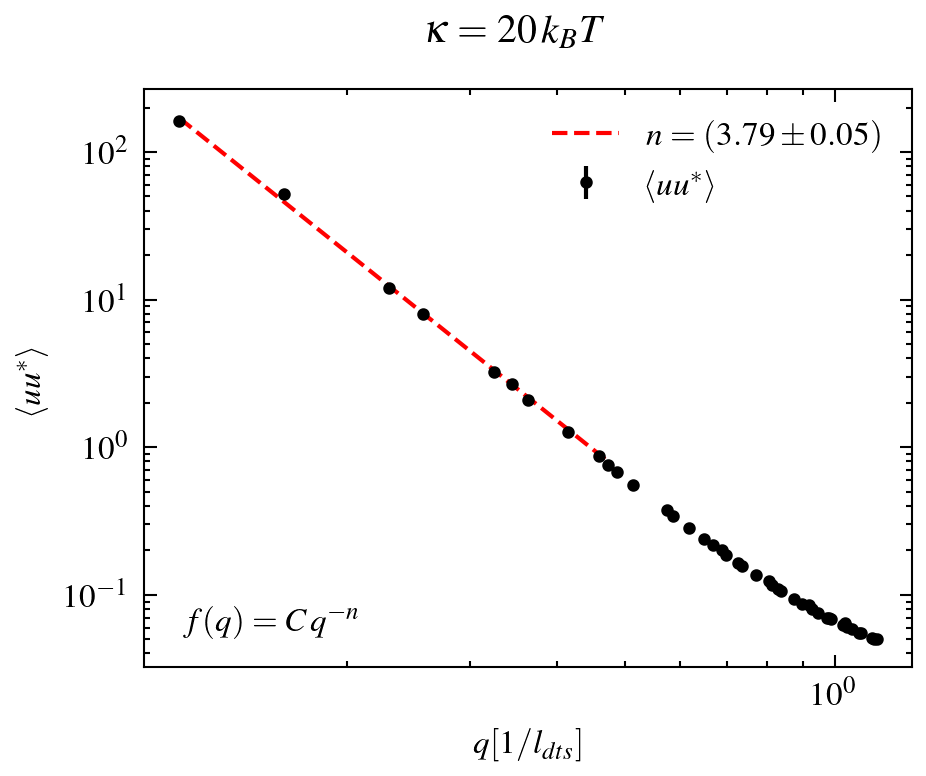

In [12]:
Simulation = "OnlyMembrane"
#Simulation = "OnlyVectorField"
spec = UndulationSpectrum(FrameTension, InitialConfiguration,Simulation, FTMethod, N_k,kappa=kappa)
spec.plot("I", i1=i1, i2=i2,fit_func=True)

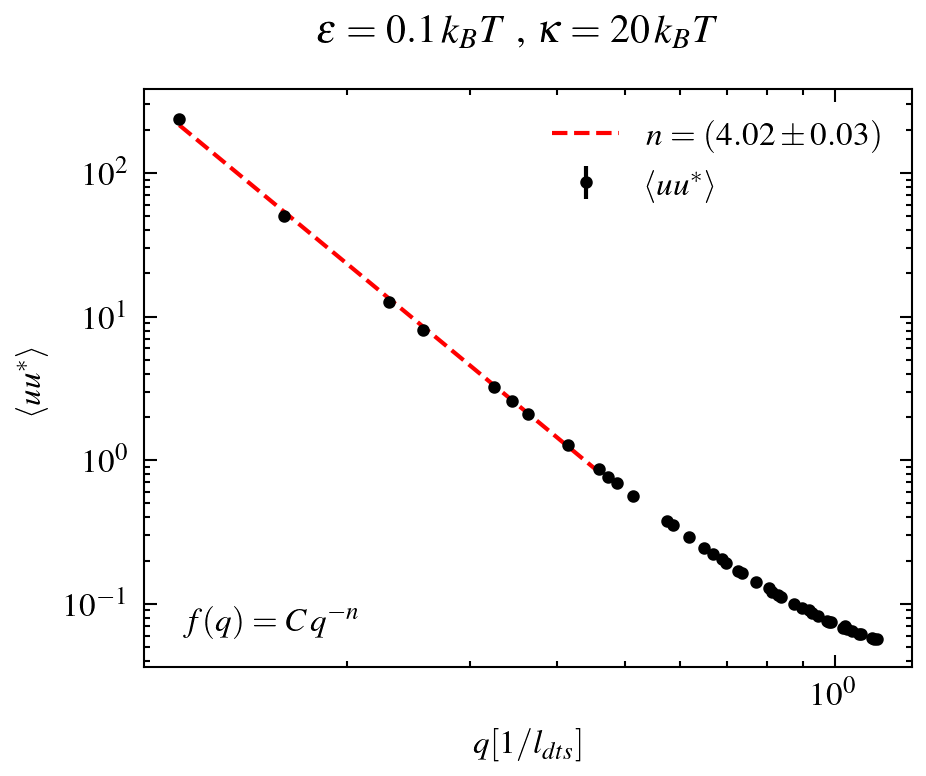

In [4]:
Simulation = "OnlyVectorField"
spec = UndulationSpectrum(FrameTension, InitialConfiguration,Simulation, FTMethod, N_k,kappa=kappa,EPS="0.1")
#spec.plot("I", i1=i1, i2=i2,fit_func=True)
spec.plot("I", i1=i1, i2=i2,fit_func=True)

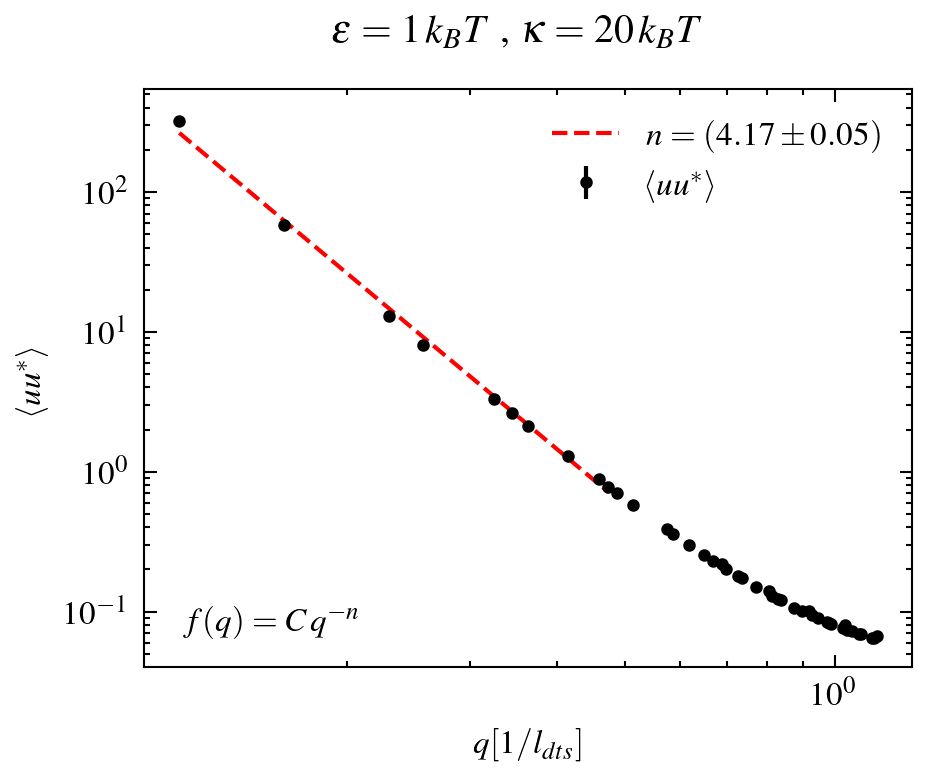

In [5]:
Simulation = "OnlyVectorField"
spec = UndulationSpectrum(FrameTension, InitialConfiguration,Simulation, FTMethod, N_k,kappa=kappa,EPS="1")
#spec.plot("I", i1=i1, i2=i2,fit_func=True)
spec.plot("I", i1=i1, i2=i2,fit_func=True)

FileNotFoundError: [Errno 2] No such file or directory: 'IsotropicFrameTension/FromFlat/OnlyMembrane/StaticUndulationSpectrum/DFT10.txt'

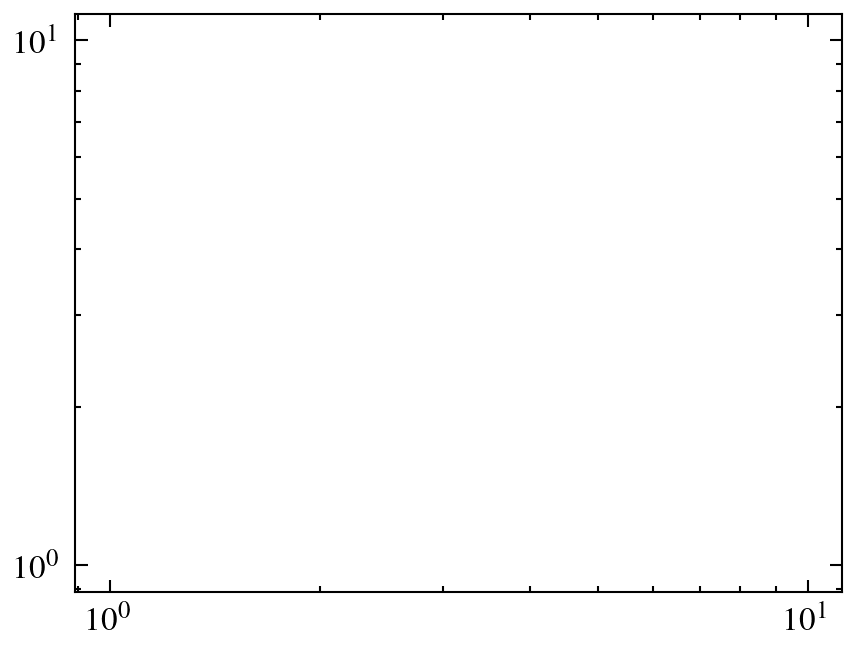

In [6]:
Simulation = "OnlyMembrane"
spec = UndulationSpectrum(FrameTension, InitialConfiguration,
                            Simulation, FTMethod, N_k)
fig, ax = spec.plot("I", i1=i1, i2=i2,return_fig=True,GroupBy=["EPS"])


Simulation = "OnlyVectorField"
spec = UndulationSpectrum(FrameTension, InitialConfiguration,
                            Simulation, FTMethod, N_k,EPS="1")
fig, ax = spec.plot("I", i1=i1, i2=i2,return_fig=True,GroupBy=["EPS"],fig=fig,ax=ax)

spec = UndulationSpectrum(FrameTension, InitialConfiguration,
                            Simulation, FTMethod, N_k,EPS="2")
fig, ax = spec.plot("I", i1=i1, i2=i2,return_fig=True,GroupBy=["EPS"],fig=fig,ax=ax)

spec = UndulationSpectrum(FrameTension, InitialConfiguration,
                            Simulation, FTMethod, N_k,EPS="5")
spec.plot("I", i1=i1, i2=i2,GroupBy=["EPS"],fig=fig,ax=ax)


# fig, ax = UndulationSpectrum(InitialConfiguration=InitialConfiguration,plot_func="q",N_bootstrap=10000,i1=0,i2=5,
#                             FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod,
#                             return_fig=True,GroupBy=["EPS"])

# Simulation = "OnlyVectorField"
# fig, ax = UndulationSpectrum(EPS="1",InitialConfiguration=InitialConfiguration,plot_func="q",N_bootstrap=10000,i1=0,i2=5,
#                             FrameTension=FrameTension,Simulation=Simulation,FTsMethod=FTMethod,
#                             return_fig=True,fig=fig,ax=ax,GroupBy=["EPS"])
# fig, ax = UndulationSpectrum(EPS="2",InitialConfiguration=InitialConfiguration,plot_func="q",N_bootstrap=10000,i1=0,i2=5,
#                             FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod,
#                             return_fig=True,fig=fig,ax=ax,GroupBy=["EPS"])
# UndulationSpectrum(EPS="5",InitialConfiguration=InitialConfiguration,plot_func="q",N_bootstrap=10000,i1=0,i2=5,
#                             FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod,
#                             fig=fig,ax=ax,GroupBy=["EPS"])


In [ ]:

Simulation = "OnlyVectorField"
UndulationSpectrum(EPS="2",InitialConfiguration=InitialConfiguration,plot_func="I",N_bootstrap=10000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

TypeError: __init__() got an unexpected keyword argument 'plot_func'

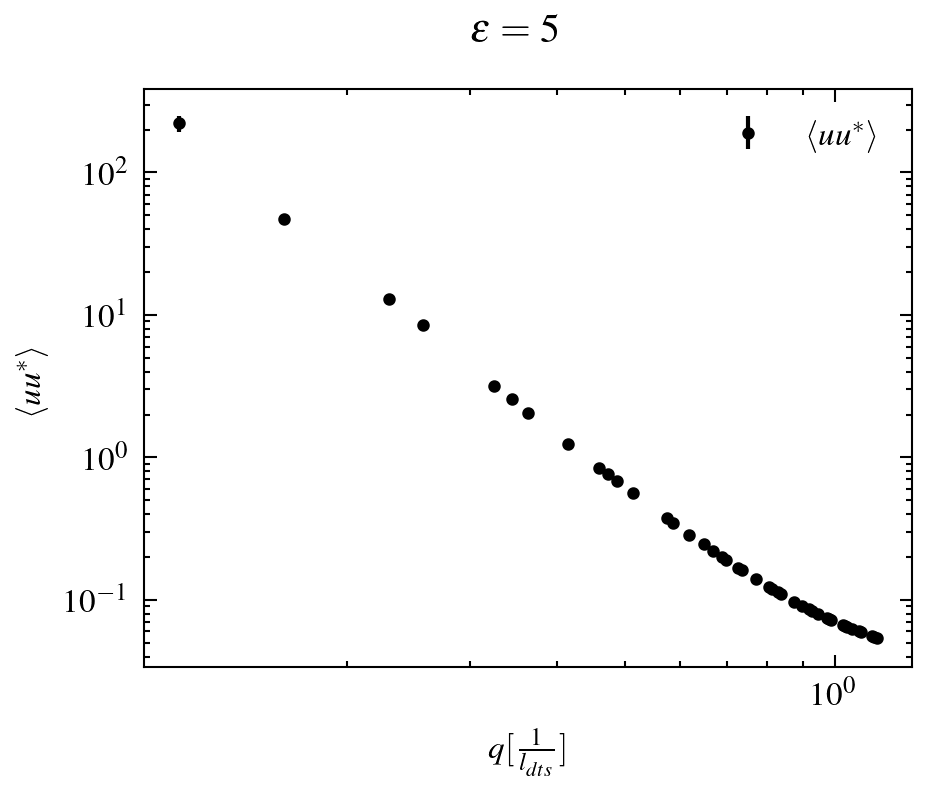

In [ ]:
Simulation = "OnlyVectorField"
UndulationSpectrum(EPS="5",InitialConfiguration=InitialConfiguration,plot_func="I",N_bootstrap=10000,i1=0,i2=5,
                   FrameTension=FrameTension,Simulation=Simulation,FTMethod=FTMethod)

In [ ]:
sfdsfd

NameError: name 'sfdsfd' is not defined

In [ ]:
Simulation = "VectorFieldMembrane"
EPS="10"
KPKL_list=[(0.1,0.05),(1,0.5),(10,5)]
for KPKL in KPKL_list:
# start bootstrapping
    for N_k in (3,5,8):
        values = np.genfromtxt(
            f"/lustre/astro/semygind/Analyzer/version_1/{Simulation}/EPS{EPS}/KP{KPKL[0]}KL{KPKL[1]}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt",
#            /lustre/astro/semygind/Analyzer/version_1/VectorFieldMembrane/EPS10/KP0.1KL0.05/StaticUndulationSpectrum/LSFT3.txt
            skip_header=7,
            delimiter=" ",
        )
        
        mean, err = bootstrap(values,N_bootstrap)
        #r"$n \pm \sigma_n$",r"$\kappa",r"$\kappa_{\parallel}$",r"\kappa_{perpindicular}$",r"$\epsilon$",r"$\xi$",r"$N_k$"
        table_data.append([
        rf"${mean[1]:.2f} \pm {err[1]:.2f}$",
        rf"${kappa}$",
        rf"${KPKL[0]}$",
        rf"${KPKL[1]}$",
        rf"${EPS}$",
        rf"$0$",
        rf"{N_k}"
        ])

    #_ = plt.hist(bootstrap_params[:,1], bins='scott', density=True, label=rf"PDF $N_k={N_k}$")
    #mu, std = norm.fit(bootstrap_params[:,1])
    #x = np.linspace(bootstrap_params[:,1].min(), bootstrap_params[:,1].max(), 300)
    #plt.plot(x, norm.pdf(x, mean, ), color='red', label=rf"$n={mu:.2f},\ \sigma={std:.2f}$")
    #plt.vlines(mu,0,norm.pdf(mu,mu,std),color="black",label="Mean",linestyles="dashed")
    #plt.legend()
    # 4.46
    # N_k5 -> 4.46
    # N_k7 -> 4.47
    # 100k -> 
#plt.show()